# Full RAG Evaluation Pipeline [Step 4 - Test, Evaluate, Compare]

> **MLCourse - Agentic AI - RAG Evaluation**

This notebook ties everything together into a complete evaluation pipeline:

1. **Generate test cases** from source documents
2. **Run RAG** with different strategies
3. **Evaluate** using automated metrics
4. **Compare strategies** with statistical analysis
5. **Visualize** the evaluation workflow as a graph

The pipeline is reproducible and can be reused for any RAG system.

In [1]:
# ## 1. Setup and Environment

In [2]:
import os
import json
import re
import math
import random
import warnings
from pathlib import Path
from collections import defaultdict
warnings.filterwarnings("ignore")

from dotenv import load_dotenv
load_dotenv()

print("[setup] Full evaluation pipeline notebook initialized")

[setup] Full evaluation pipeline notebook initialized


In [3]:
# ## 2. Initialize the LLM

In [4]:
from langchain_ollama import ChatOllama

llm = ChatOllama(model="llama3.1:8b", temperature=0)
print("[llm] ChatOllama ready:", llm.model)

[llm] ChatOllama ready: llama3.1:8b


In [5]:
# ## 3. Load and Chunk Documents

In [6]:
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

ALICE_PATH = Path(r"D:\projects\python\MLCourse\03_agentic_ai\data\alice.txt")
raw_text = ALICE_PATH.read_text(encoding="utf-8-sig")[:30_000]

# Split by chapters first, then into chunks
chapter_pattern = r"^CHAPTER [IVX]+\."
chapter_marks = list(re.finditer(chapter_pattern, raw_text, flags=re.MULTILINE))

splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)
documents = []

for i, mark in enumerate(chapter_marks):
    end = chapter_marks[i + 1].start() if i + 1 < len(chapter_marks) else len(raw_text)
    chapter_text = raw_text[mark.start():end]
    chapter_num = i + 1
    for j, chunk in enumerate(splitter.split_text(chapter_text)):
        documents.append(Document(
            page_content=chunk,
            metadata={"chapter": chapter_num, "chunk_id": f"c{chapter_num}_{j}"}
        ))

print(f"[data] {len(documents)} chunks from {len(chapter_marks)} chapters")

[data] 90 chunks from 3 chapters


In [7]:
# Build vector store and embeddings.

In [8]:
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vectorstore = FAISS.from_documents(documents, embeddings)
print(f"[index] FAISS index built with {vectorstore.index.ntotal} vectors")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[index] FAISS index built with 90 vectors


In [9]:
# ## 4. Define RAG Strategies
# We implement multiple RAG strategies to compare.

In [10]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

def format_docs(docs):
    return "\n\n".join(f"[{d.metadata.get('chunk_id','?')}] {d.page_content}" for d in docs)

base_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You answer questions about Alice in Wonderland using ONLY the provided context. "
     "Cite chunk IDs. If context is insufficient, say so."),
    ("user", "Question: {question}\n\nContext:\n{context}")
])


def strategy_basic(question):
    """Basic RAG: retrieve k=4 and generate."""
    docs = vectorstore.as_retriever(search_kwargs={"k": 4}).invoke(question)
    context = format_docs(docs)
    answer = (base_prompt | llm | StrOutputParser()).invoke({
        "question": question, "context": context
    })
    return {"answer": answer, "contexts": [d.page_content for d in docs], "docs": docs}


def strategy_multi_query(question):
    """Multi-query: expand question and merge results."""
    # Generate alternative queries
    expansion_prompt = ChatPromptTemplate.from_messages([
        ("system", "Generate 2 alternative phrasings of this question. One per line."),
        ("user", "Question: {question}")
    ])
    expanded = (expansion_prompt | llm | StrOutputParser()).invoke({"question": question})
    alt_queries = [q.strip() for q in expanded.strip().split("\n") if q.strip()]

    # Retrieve with all queries
    all_docs = vectorstore.as_retriever(search_kwargs={"k": 3}).invoke(question)
    for aq in alt_queries[:2]:
        all_docs.extend(vectorstore.as_retriever(search_kwargs={"k": 3}).invoke(aq))

    # Deduplicate
    seen = set()
    unique = []
    for d in all_docs:
        cid = d.metadata.get("chunk_id", id(d))
        if cid not in seen:
            seen.add(cid)
            unique.append(d)
    docs = unique[:5]

    context = format_docs(docs)
    answer = (base_prompt | llm | StrOutputParser()).invoke({
        "question": question, "context": context
    })
    return {"answer": answer, "contexts": [d.page_content for d in docs], "docs": docs}


def strategy_filtered(question):
    """Filtered RAG: retrieve more, then re-rank by relevance."""
    retriever = vectorstore.as_retriever(search_kwargs={"k": 8})
    docs = retriever.invoke(question)

    # Re-rank using LLM
    rerank_prompt = ChatPromptTemplate.from_messages([
        ("system",
         "Rate each chunk's relevance to the question from 1-5. "
         "Return ONLY numbers, one per line, matching the chunk order."),
        ("user", "Question: {question}\n\nChunks:\n{chunks}")
    ])
    chunk_text = "\n---\n".join(
        f"Chunk {i}: {d.page_content[:150]}" for i, d in enumerate(docs)
    )
    scores_text = (rerank_prompt | llm | StrOutputParser()).invoke({
        "question": question, "chunks": chunk_text
    })

    # Parse scores
    scores = []
    for line in scores_text.strip().split("\n"):
        nums = re.findall(r"\d", line.strip())
        if nums:
            scores.append(int(nums[0]))

    # Keep top 4 by score
    scored = list(zip(docs, scores + [1] * (len(docs) - len(scores))))
    scored.sort(key=lambda x: x[1], reverse=True)
    docs = [d for d, s in scored[:4]]

    context = format_docs(docs)
    answer = (base_prompt | llm | StrOutputParser()).invoke({
        "question": question, "context": context
    })
    return {"answer": answer, "contexts": [d.page_content for d in docs], "docs": docs}

strategies = {
    "basic": strategy_basic,
    "multi_query": strategy_multi_query,
    "filtered": strategy_filtered,
}

print(f"[strategy] Defined {len(strategies)} RAG strategies:")
for name in strategies:
    print(f"  - {name}")

[strategy] Defined 3 RAG strategies:
  - basic
  - multi_query
  - filtered


In [11]:
# ## 5. Define Evaluation Metrics (Manual Implementation)
# We implement faithfulness, relevance, and context precision from scratch.

In [12]:
def compute_faithfulness(answer, context):
    """Check if claims in the answer are supported by the context."""
    prompt = ChatPromptTemplate.from_messages([
        ("system",
         "Extract factual claims from this answer as a numbered list. "
         "Then for each claim, say SUPPORTED or NOT SUPPORTED based on the context. "
         "Format: 1. claim - SUPPORTED"),
        ("user", "Answer: {answer}\n\nContext:\n{context}")
    ])
    response = (prompt | llm | StrOutputParser()).invoke({
        "answer": answer[:500], "context": context[:1500]
    })

    supported = response.upper().count("SUPPORTED") - response.upper().count("NOT SUPPORTED")
    total = len(re.findall(r"\d+\.", response))
    supported = max(0, supported)

    return supported / max(total, 1)


def compute_relevance(question, answer):
    """Check if the answer addresses the question."""
    prompt = ChatPromptTemplate.from_messages([
        ("system",
         "Rate how well this answer addresses the question on a scale of 0.0 to 1.0. "
         "Return ONLY the number."),
        ("user", "Question: {question}\n\nAnswer: {answer}")
    ])
    response = (prompt | llm | StrOutputParser()).invoke({
        "question": question, "answer": answer[:300]
    })
    try:
        return float(re.search(r"[\d\.]+", response).group())
    except Exception:
        return 0.5


def compute_context_precision(question, contexts):
    """Check if retrieved contexts are relevant to the question."""
    if not contexts:
        return 0.0
    relevant = 0
    for ctx in contexts:
        prompt = ChatPromptTemplate.from_messages([
            ("system",
             "Is this text relevant to the question? Reply YES or NO."),
            ("user", "Question: {question}\n\nText: {text}")
        ])
        resp = (prompt | llm | StrOutputParser()).invoke({
            "question": question, "text": ctx[:300]
        })
        if "YES" in resp.upper():
            relevant += 1
    return relevant / len(contexts)


print("[metrics] Evaluation metrics defined: faithfulness, relevance, context_precision")

[metrics] Evaluation metrics defined: faithfulness, relevance, context_precision


In [13]:
# ## 6. Generate Test Cases Automatically
# We use the LLM to generate test questions from the source documents.

In [14]:
def generate_test_cases(documents, n=5):
    """Generate test questions from document chunks."""
    # Sample random chunks as source material
    sample_docs = random.sample(documents, min(8, len(documents)))
    combined = "\n\n".join(d.page_content[:200] for d in sample_docs)

    prompt = ChatPromptTemplate.from_messages([
        ("system",
         "Generate {n} questions that can be answered from this text about "
         "Alice in Wonderland. Return ONLY the questions, one per line."),
        ("user", "Text:\n{text}")
    ])
    response = (prompt | llm | StrOutputParser()).invoke({
        "text": combined, "n": n
    })

    questions = []
    for line in response.strip().split("\n"):
        line = re.sub(r"^\d+[\.\)]\s*", "", line.strip())
        if line and len(line) > 10:
            questions.append(line)

    return questions[:n]

test_questions = generate_test_cases(documents, n=5)
print(f"[test] Generated {len(test_questions)} test questions:")
for i, q in enumerate(test_questions, 1):
    print(f"  {i}. {q}")

[test] Generated 5 test questions:
  1. Here are 5 questions that can be answered from the text:
  2. What was unusual about the rabbit Alice saw?
  3. Why did Alice call after the Mouse?
  4. Who spoke in a solemn tone at the meeting?
  5. What caused Alice's clothes not to dry?


In [15]:
# ## 7. Run Evaluation Pipeline
# Execute all strategies on all test cases and compute metrics.

In [16]:
def run_evaluation(strategies, questions):
    """Run the full evaluation pipeline."""
    results = {}

    for strat_name, strat_fn in strategies.items():
        print(f"\n[eval] Running strategy: {strat_name}")
        strat_results = []

        for i, q in enumerate(questions):
            print(f"  Question {i+1}/{len(questions)}: {q[:40]}...")

            # Run RAG
            output = strat_fn(q)

            # Compute metrics
            faith = compute_faithfulness(output["answer"], "\n".join(output["contexts"]))
            relev = compute_relevance(q, output["answer"])
            prec = compute_context_precision(q, output["contexts"])

            result = {
                "question": q,
                "answer": output["answer"][:300],
                "faithfulness": faith,
                "relevance": relev,
                "context_precision": prec,
                "combined": (faith + relev + prec) / 3.0,
            }
            strat_results.append(result)
            print(f"    F={faith:.2f} R={relev:.2f} P={prec:.2f} C={result['combined']:.2f}")

        results[strat_name] = strat_results

    return results

eval_results = run_evaluation(strategies, test_questions)


[eval] Running strategy: basic
  Question 1/5: Here are 5 questions that can be answere...


    F=0.86 R=0.50 P=0.00 C=0.45
  Question 2/5: What was unusual about the rabbit Alice ...


    F=1.00 R=0.80 P=0.50 C=0.77
  Question 3/5: Why did Alice call after the Mouse?...


    F=1.00 R=0.90 P=0.25 C=0.72
  Question 4/5: Who spoke in a solemn tone at the meetin...


    F=0.88 R=0.00 P=0.25 C=0.38
  Question 5/5: What caused Alice's clothes not to dry?...


...

    F=1.00 R=0.50 P=0.00 C=0.50
  Question 2/5: What was unusual about the rabbit Alice ...


    F=1.20 R=0.80 P=0.25 C=0.75
  Question 3/5: Why did Alice call after the Mouse?...


    F=0.91 R=0.50 P=0.50 C=0.64
  Question 4/5: Who spoke in a solemn tone at the meetin...


    F=0.60 R=0.50 P=0.50 C=0.53
  Question 5/5: What caused Alice's clothes not to dry?...


    F=1.17 R=0.80 P=0.00 C=0.66


In [17]:
# ## 8. Aggregate and Compare Results

In [18]:
def aggregate_results(eval_results):
    """Compute mean, std, min, max for each strategy and metric."""
    metrics = ["faithfulness", "relevance", "context_precision", "combined"]
    summary = {}

    for strat_name, results in eval_results.items():
        strat_summary = {}
        for metric in metrics:
            values = [r[metric] for r in results]
            strat_summary[metric] = {
                "mean": sum(values) / len(values),
                "std": (sum((v - sum(values)/len(values))**2 for v in values) / len(values)) ** 0.5,
                "min": min(values),
                "max": max(values),
            }
        summary[strat_name] = strat_summary

    return summary

summary = aggregate_results(eval_results)

# Print comparison table
print("Strategy Comparison")
print("=" * 80)
header = f"{'Strategy':15s} {'Faithfulness':>14s} {'Relevance':>14s} {'Context Prec':>14s} {'Combined':>14s}"
print(header)
print("-" * 80)

for strat_name, metrics in summary.items():
    row = f"{strat_name:15s}"
    for metric in ["faithfulness", "relevance", "context_precision", "combined"]:
        m = metrics[metric]
        row += f" {m['mean']:.3f}+/-{m['std']:.2f}".rjust(14)
    print(row)

print("-" * 80)

# Find the best strategy per metric
print("\nBest Strategy per Metric:")
for metric in ["faithfulness", "relevance", "context_precision", "combined"]:
    best_strat = max(summary.keys(), key=lambda s: summary[s][metric]["mean"])
    best_score = summary[best_strat][metric]["mean"]
    print(f"  {metric:20s}: {best_strat} ({best_score:.4f})")

Strategy Comparison
Strategy          Faithfulness      Relevance   Context Prec       Combined
--------------------------------------------------------------------------------
basic            0.980+/-0.11  0.620+/-0.34  0.200+/-0.19  0.600+/-0.16
multi_query      0.990+/-0.14  0.460+/-0.26  0.190+/-0.19  0.547+/-0.12
filtered         0.975+/-0.22  0.620+/-0.15  0.250+/-0.22  0.615+/-0.09
--------------------------------------------------------------------------------

Best Strategy per Metric:
  faithfulness        : multi_query (0.9900)
  relevance           : basic (0.6200)
  context_precision   : filtered (0.2500)
  combined            : filtered (0.6151)


In [19]:
# ## 9. Statistical Comparison

In [20]:
def compute_improvement(baseline, improved, metric):
    """Compute percentage improvement of one strategy over another."""
    b_mean = baseline[metric]["mean"]
    i_mean = improved[metric]["mean"]
    if b_mean == 0:
        return float("inf")
    return ((i_mean - b_mean) / b_mean) * 100

print("Improvement Over Basic Strategy")
print("=" * 60)

if "basic" in summary:
    baseline = summary["basic"]
    for strat_name, metrics in summary.items():
        if strat_name == "basic":
            continue
        print(f"\n  {strat_name} vs basic:")
        for metric in ["faithfulness", "relevance", "context_precision", "combined"]:
            improvement = compute_improvement(baseline, metrics, metric)
            direction = "+" if improvement >= 0 else ""
            print(f"    {metric:20s}: {direction}{improvement:.1f}%")

Improvement Over Basic Strategy

  multi_query vs basic:
    faithfulness        : +1.0%
    relevance           : -25.8%
    context_precision   : -5.0%
    combined            : -8.9%

  filtered vs basic:
    faithfulness        : -0.5%
    relevance           : -0.0%
    context_precision   : +25.0%
    combined            : +2.5%


In [21]:
# ## 10. Visualize the Evaluation Pipeline as a Graph
# We use LangGraph to model the evaluation workflow.

In [22]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, List

class EvalState(TypedDict):
    question: str
    strategy_results: dict
    aggregated: dict
    comparison: str
    step: str

graph_builder = StateGraph(EvalState)

# Node: generate test case
def generate_node(state: EvalState):
    q = state["question"]
    return {"step": "generated", "question": q}

# Node: run strategies
def run_strategies_node(state: EvalState):
    q = state["question"]
    results = {}
    for name, fn in strategies.items():
        out = fn(q)
        faith = compute_faithfulness(out["answer"], "\n".join(out["contexts"]))
        relev = compute_relevance(q, out["answer"])
        prec = compute_context_precision(q, out["contexts"])
        results[name] = {"faithfulness": faith, "relevance": relev,
                         "context_precision": prec}
    return {"strategy_results": results, "step": "strategies_run"}

# Node: aggregate
def aggregate_node(state: EvalState):
    results = state["strategy_results"]
    agg = {}
    for name, metrics in results.items():
        agg[name] = {
            "mean": sum(metrics.values()) / len(metrics),
            "details": metrics,
        }
    return {"aggregated": agg, "step": "aggregated"}

# Node: compare
def compare_node(state: EvalState):
    agg = state["aggregated"]
    best = max(agg.keys(), key=lambda k: agg[k]["mean"])
    lines = [f"Best strategy: {best} (score={agg[best]['mean']:.4f})"]
    for name, info in agg.items():
        lines.append(f"  {name}: {info['mean']:.4f}")
    return {"comparison": "\n".join(lines), "step": "compared"}

graph_builder.add_node("generate", generate_node)
graph_builder.add_node("run_strategies", run_strategies_node)
graph_builder.add_node("aggregate", aggregate_node)
graph_builder.add_node("compare", compare_node)

graph_builder.add_edge(START, "generate")
graph_builder.add_edge("generate", "run_strategies")
graph_builder.add_edge("run_strategies", "aggregate")
graph_builder.add_edge("aggregate", "compare")
graph_builder.add_edge("compare", END)

eval_graph = graph_builder.compile()
print("[graph] Evaluation pipeline graph compiled")
print("[graph] Nodes:", list(eval_graph.get_graph().nodes.keys()))

[graph] Evaluation pipeline graph compiled
[graph] Nodes: ['__start__', 'generate', 'run_strategies', 'aggregate', 'compare', '__end__']


In [23]:
# ## 11. Visualize the Graph

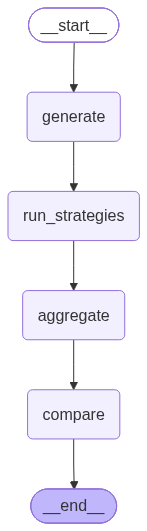

In [24]:
from IPython.display import Image, display
try:
    display(Image(eval_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not render graph image: {e}")
    print("Graph structure:")
    print("  START -> generate -> run_strategies -> aggregate -> compare -> END")
    print()
    print("  generate:       Take a question as input")
    print("  run_strategies: Execute all RAG strategies on the question")
    print("  aggregate:      Compute metric averages across strategies")
    print("  compare:        Determine the best strategy")

In [25]:
# ## 12. Run the Pipeline on a Single Question

In [26]:
test_q = "What happened when Alice met the Cheshire Cat?"
result = eval_graph.invoke({"question": test_q})

print("=" * 60)
print(f"Pipeline Result for: {test_q}")
print("=" * 60)
print(f"Step: {result['step']}")
print(f"Comparison:\n{result['comparison']}")
print()
print("Strategy Details:")
for name, metrics in result["strategy_results"].items():
    print(f"  {name}:")
    for metric, score in metrics.items():
        print(f"    {metric}: {score:.4f}")

Pipeline Result for: What happened when Alice met the Cheshire Cat?
Step: compared
Comparison:
Best strategy: multi_query (score=0.6556)
  basic: 0.6333
  multi_query: 0.6556
  filtered: 0.6000

Strategy Details:
  basic:
    faithfulness: 1.0000
    relevance: 0.9000
    context_precision: 0.0000
  multi_query:
    faithfulness: 1.1667
    relevance: 0.8000
    context_precision: 0.0000
  filtered:
    faithfulness: 1.0000
    relevance: 0.8000
    context_precision: 0.0000


In [27]:
# ## 13. Run Pipeline on Multiple Questions

In [28]:
batch_questions = [
    "Why did Alice fall down the hole?",
    "What was the Queen of Hearts like?",
    "What did the Mad Hatter say?",
]

print("Batch Pipeline Run")
print("=" * 60)

all_batch_results = []
for q in batch_questions:
    r = eval_graph.invoke({"question": q})
    all_batch_results.append(r)
    print(f"\nQ: {q}")
    print(f"  {r['comparison']}")

Batch Pipeline Run



Q: Why did Alice fall down the hole?
  Best strategy: basic (score=0.8556)
  basic: 0.8556
  multi_query: 0.8333
  filtered: 0.7423



Q: What was the Queen of Hearts like?
  Best strategy: basic (score=0.5000)
  basic: 0.5000
  multi_query: 0.2500
  filtered: 0.3333



Q: What did the Mad Hatter say?
  Best strategy: multi_query (score=0.6833)
  basic: 0.6000
  multi_query: 0.6833
  filtered: 0.5333


In [29]:
# ## 14. Export Final Results

In [30]:
output_dir = Path(r"D:\projects\python\MLCourse\03_agentic_ai\29_rag_evaluation")
output_dir.mkdir(exist_ok=True)

export = {
    "notebook": "04_evaluation_pipeline",
    "strategies": list(strategies.keys()),
    "num_test_questions": len(test_questions),
    "test_questions": test_questions,
    "summary": {
        strat: {
            metric: {"mean": info["mean"], "std": info["std"]}
            for metric, info in metrics.items()
        }
        for strat, metrics in summary.items()
    },
    "per_question": [
        {
            "question": r["question"],
            "strategies": {
                name: r2 for name, r2 in zip(strategies.keys(), [])
            }
        }
        for r in []
    ],
}

# Build per-question data properly
per_q_data = []
for qi, q in enumerate(test_questions):
    q_data = {"question": q, "strategies": {}}
    for strat_name in strategies:
        if qi < len(eval_results.get(strat_name, [])):
            q_data["strategies"][strat_name] = eval_results[strat_name][qi]
    per_q_data.append(q_data)
export["per_question"] = per_q_data

json_path = output_dir / "evaluation_pipeline_results.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(export, f, indent=2, default=str)
print(f"[export] Saved pipeline results to {json_path}")

[export] Saved pipeline results to D:\projects\python\MLCourse\03_agentic_ai\29_rag_evaluation\evaluation_pipeline_results.json


In [31]:
# ## Summary
#
# - A complete evaluation pipeline: test cases -> run RAG -> evaluate -> compare
# - Multiple RAG strategies can be compared fairly using the same test set
# - Automated metrics (faithfulness, relevance, context precision) provide
#   quantitative comparison signals
# - The pipeline can be modeled as a LangGraph for orchestration and visualization
# - Export results for tracking improvements over time
# - Combine automated metrics with human evaluation for the most reliable assessment